# Haltestellen im Verkehrsverbund Steiermark

Univariate descriptive analysis for the master's thesis.

**Source:** OGD/Haltestellen.zip

In [1]:
import os
import sys
os.chdir(r"D:\CO2_Masterarbeit\CO2_Masterarbeit")
sys.path.insert(0, r"D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from plotting.apa7 import set_apa7_style, new_figure, save_apa7, BAR_KWARGS, HIST_KWARGS, LINE_KWARGS

set_apa7_style()

In [2]:
stops = gpd.read_file("OGD/Haltestellen.zip")
stops["Abfahrten"].describe()

count     8221.000000
mean       112.688237
std        366.764479
min          0.000000
25%          3.000000
50%         14.000000
75%         63.000000
max      10322.000000
Name: Abfahrten, dtype: float64

## Scheduled departures per stop

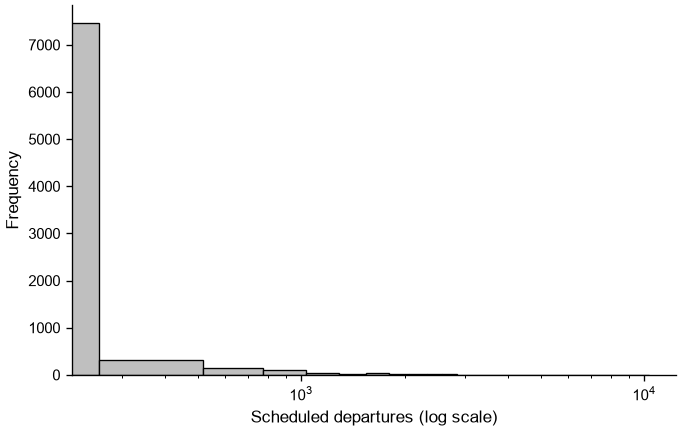

In [3]:
fig, ax = new_figure()
ax.hist(stops["Abfahrten"].dropna(), bins=40, **HIST_KWARGS)
ax.set_xscale("log")
ax.set(xlabel="Scheduled departures (log scale)", ylabel="Frequency")
save_apa7(fig, "FIG/Haltestellen/figure_1_departures_distribution.png")
save_apa7(fig, "FIG/Haltestellen/figure_1_departures_distribution.svg")
plt.show()

## Stops by tariff zone

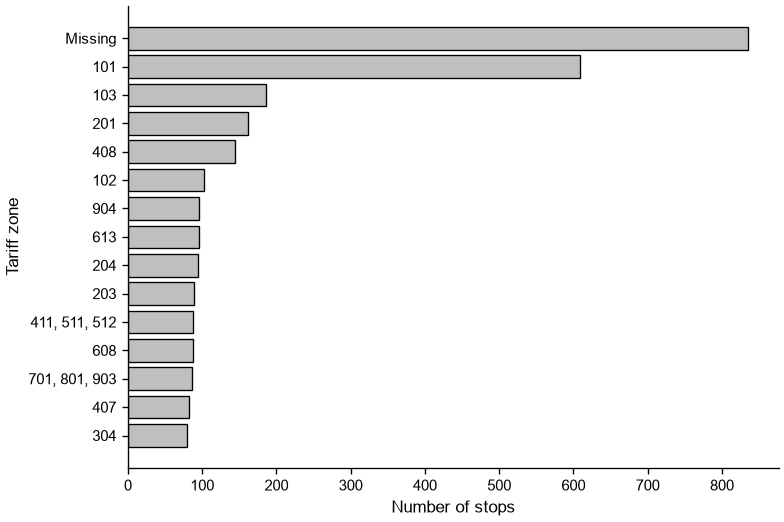

In [4]:
counts = stops["TARIFZONEN"].fillna("Missing").value_counts().head(15).sort_values()
fig, ax = new_figure(7, 5)
ax.barh(counts.index, counts.values, **BAR_KWARGS)
ax.set(xlabel="Number of stops", ylabel="Tariff zone")
save_apa7(fig, "FIG/Haltestellen/figure_2_stops_by_tariff_zone.png")
save_apa7(fig, "FIG/Haltestellen/figure_2_stops_by_tariff_zone.svg")
plt.show()